In [5]:
import sys
from pathlib import Path
NOTEBOOKS = Path.cwd()
NEURALNET = NOTEBOOKS.parents[0]
BAMBOO_SETUP = NEURALNET.parents[1]                           
sys.path.append(str((BAMBOO_SETUP/'src').resolve()))
import pandas as pd
pd.set_option('display.max_columns', None)  # Display all columns
pd.set_option('display.width', 1000)  # Set a larger width to fit the editor window

Z_OUTPUT_local = Path('/Users/antonett/Documents/HH Analysis/Z_OUTPUT_eos') 
Z_OUTPUT_eos = Path('/eos/user/a/anunezde/Z_OUTPUT_eos')
first_dir = str(NOTEBOOKS).split('/')[1]
Z_OUTPUT_current = Z_OUTPUT_eos if first_dir == 'afs' else Z_OUTPUT_local

%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
from NeuralNet.DataHandler import DataHandler
import logging
datahandler = DataHandler(
    workdir=Z_OUTPUT_current/'2022_even_1101/Reco_SLres2bx',
    tree_name='SL_res_2b_x',
    log_level=logging.INFO
)
# total_df = datahandler.start()
total_df_unprep = datahandler.load_data()
total_df_unprep = datahandler.fix_column_names_mismatch(total_df_unprep)



Loading data...



Data inspection ... 
	Duplicate events:


		Number of duplicate events found: 8742
	Negative genWeights:
		Number of events with negative genWeights: 14290
	Null Values (i.e NaN, None):
		No events with null values found.
	Additional checks on numeric features only:
		No events with inf values found.
		No events with features larger than abs(10000.0) found.

Preprocessing data ...
	Dropping exact duplicates if any ...
	Removing events with negative weights ...

Data inspection ... 
	Duplicate events:
		No duplicate events found.
	Negative genWeights:
		No events with negative genWeights found.
	Null Values (i.e NaN, None):
		No events with null values found.
	Additional checks on numeric features only:
		No events with inf values found.
		No events with features larger than abs(10000.0) found.


In [12]:
df

,event,run,luminosityBlock,genWeight,bunchCrossing,genTtbarId,met_pt,met_phi,nAK4,nAK4_btag,nAK4_nonbtag,nAK8_btag,ak4_jet0_pt,ak4_jet0_phi,ak4_jet0_eta,ak4_jet0_bscore,ak4_jet1_pt,ak4_jet1_phi,ak4_jet1_eta,ak4_jet1_bscore,ak4_jet2_pt,ak4_jet2_phi,ak4_jet2_eta,ak4_jet2_bscore,ak4_jet3_pt,ak4_jet3_phi,ak4_jet3_eta,ak4_jet3_bscore,ak4_jet4_pt,ak4_jet4_phi,ak4_jet4_eta,ak4_jet4_bscore,ak4_jet5_pt,ak4_jet5_phi,ak4_jet5_eta,ak4_jet5_bscore,lep0_pt,lep0_phi,lep0_eta,lep0_iso,trijet_mInv,trijet_pt,trijet_pt_rat,blnu_mT,blnu_pt,trijet_bijet_dR,trijet_bijet_dPhi,trijet_bijet_dEta,bjet_bijet_dR,bjet_bijet_dPhi,bjet_bijet_dEta,all_sT,all_sT_50_cut,all_mInv,all_mT,all_jets_HT,all_pt,mjj,WW_mInv,WW_pt,bjets_mbb,bjets_dPhi,bjets_dPhi_abs,bjets_dEta,bjets_dEta_abs,bjets_dR,bjets_pt_bb,bjet0_pt,bjet1_pt,bjets_mean_pt,File,Process
245117,18,1,1,3.805950,4294967295,151,116.074379,-2.936035,4,2,2,0,172.5000,0.624268,1.684570,0.511719,111.3750,-1.235596,1.175537,0.027573,70.37500,1.242432,0.964478,0.953125,26.40625,-1.787109,1.070068,0.023514,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.00000,-9999.000000,-9999.000000,-9999.000000,89.622681,-2.818848,1.105957,0.000000,275.532318,173.572144,0.559403,315.133392,176.526657,1.441196,-1.164057,0.849716,2.027832,-1.962857,0.509210,586.353310,559.947060,697.857056,698.050232,380.656250,16.421644,41.493786,310.004181,248.251236,111.787468,-0.618164,0.618164,-0.720093,0.720093,0.949031,233.442108,70.37500,172.50000,121.437500,tbarWplus_dl,tW
2242770,22,1,1,337.046997,4294967295,200,65.833290,-1.534180,6,2,4,0,257.7500,-1.596436,-1.424072,0.654297,94.8750,1.199707,0.773926,0.004173,80.68750,1.161865,1.667236,0.007786,63.68750,2.514160,-0.887573,0.003674,37.687500,2.004883,1.211914,0.991699,33.15625,2.544434,1.619873,0.034943,24.002106,0.132206,-1.138565,0.000000,114.136292,203.058990,0.952211,406.004089,320.889313,0.140181,-0.136447,0.032135,0.824454,-0.822567,-0.055745,657.679146,562.833290,1253.854858,1255.707031,567.843750,68.177055,84.452141,351.268646,136.223877,393.151337,2.681867,2.681867,2.635986,2.635986,3.760430,224.598801,37.68750,257.75000,147.718750,TTbar_sl,ttbar
16422,32,1,1,0.033119,4294967295,53,32.159973,2.111816,4,2,2,0,192.0000,-1.602783,-0.145477,0.824707,125.8125,1.625244,0.816772,0.004314,50.75000,-0.813354,-0.764038,0.999512,34.09375,-2.734375,1.646729,0.006004,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.00000,-9999.000000,-9999.000000,-9999.000000,65.667160,1.424072,1.346191,0.010235,414.172607,91.249809,0.259301,221.209976,62.258396,2.308760,-2.306782,0.095544,3.132029,-2.781621,-1.439511,500.483383,434.229660,644.934692,645.593750,402.656250,29.164007,122.545013,199.450302,209.565338,101.529617,-0.789429,0.789429,-0.618561,0.618561,1.002903,230.573227,50.75000,192.00000,121.375000,bbWW_sl,HH_bbWW
506545,36,1,1,81.103897,4294967295,242,183.191925,1.643311,5,2,3,0,156.3750,-1.665039,-1.606689,0.060364,81.3125,0.167908,1.302246,0.989258,61.37500,-1.079590,-0.245758,0.015251,57.18750,-2.950195,-0.330811,0.869629,26.500000,0.885132,-1.721436,0.009369,-9999.00000,-9999.000000,-9999.000000,-9999.000000,67.785812,2.238770,0.904053,0.000000,255.434219,224.622360,0.816994,389.353455,250.756989,0.255890,0.255418,0.015531,1.784749,1.447144,1.044559,633.727737,607.227737,1012.982605,1014.184021,382.750000,49.349865,158.995483,677.798035,48.638073,186.289108,-3.118103,3.118103,1.633057,1.633057,3.519864,24.178112,81.31250,57.18750,69.250000,TTbar_dl,ttbar
16423,42,1,1,0.033119,4294967295,10053,17.724852,-3.136719,5,2,3,0,107.0625,0.425049,1.249756,0.010193,100.6875,-2.758301,2.201172,0.999023,69.25000,0.727173,1.812744,0.073425,66.93750,-1.680908,1.660645,0.998535,27.171875,-2.252441,0.600220,0.033142,-9999.00000,-9999.000000,-9999.000000,-9999.000000,36.858803,0.675903,0.859253,0.013671,207.233261,143.871246,0.591454,212.537613,83.649582,0.651851,0.378334,0.530823,2.229081,2.224385,0.144626,425.693029,343.937500,503.722900,505.653351,371.109375,44.142178,58.874733,1

In [10]:
%autoreload 2

# Run DNN

In [11]:
from NeuralNet.utils import ModelConfig
from NeuralNet.DNNModel import DNNModel, draw_all_stats

model_config = ModelConfig(
    name='multi_HH_ttbar_tW',
    type='multi',
    categorization={"HH": ["HH_bbWW"], "ttbar": ["ttbar"], "tW": ["tW"]},
    training_weight_sf={"HH_bbWW": 1.0, "ttbar": 8.0, "tW": 4.0},
    input_vars='All',
    architecture='def model_check_default_fast',
    compiler={"optimizer": 'adam', "lr": 0.001, "loss": 'categorical_crossentropy'},
    fit={"batch_size": 1024, "epochs": 35, "validation_split": 0.25}
)

DNN = DNNModel(model_config=model_config, modeldir= NOTEBOOKS/'model_custom', log_level=logging.DEBUG)
model_df = DNN.set_model_df_from_total_df(df)
X_train, X_test, Y_train, Y_test, evs_test, sw_train = DNN.Full_Splitting(model_df)

print("Model_df:")
model_df

Initializing model: multi_HH_ttbar_tW
HH_bbWW
Total sum of genWeights for HH_bbWW: 137.84710693359375 
Total sum of sample_weights for HH_bbWW: 2340789.0333862305 
ttbar
Total sum of genWeights for ttbar: 414463904.0 
Total sum of sample_weights for ttbar: 18726312.040212628 
tW
Total sum of genWeights for tW: 10632856.0 
Total sum of sample_weights for tW: 9363156.767422235 


Model_df:


,event,genWeight,met_pt,met_phi,nAK4,nAK4_btag,nAK4_nonbtag,nAK8_btag,ak4_jet0_pt,ak4_jet0_phi,ak4_jet0_eta,ak4_jet0_bscore,ak4_jet1_pt,ak4_jet1_phi,ak4_jet1_eta,ak4_jet1_bscore,ak4_jet2_pt,ak4_jet2_phi,ak4_jet2_eta,ak4_jet2_bscore,ak4_jet3_pt,ak4_jet3_phi,ak4_jet3_eta,ak4_jet3_bscore,ak4_jet4_pt,ak4_jet4_phi,ak4_jet4_eta,ak4_jet4_bscore,ak4_jet5_pt,ak4_jet5_phi,ak4_jet5_eta,ak4_jet5_bscore,lep0_pt,lep0_phi,lep0_eta,lep0_iso,trijet_mInv,trijet_pt,trijet_pt_rat,blnu_mT,blnu_pt,trijet_bijet_dR,trijet_bijet_dPhi,trijet_bijet_dEta,bjet_bijet_dR,bjet_bijet_dPhi,bjet_bijet_dEta,all_sT,all_sT_50_cut,all_mInv,all_mT,all_jets_HT,all_pt,mjj,WW_mInv,WW_pt,bjets_mbb,bjets_dPhi,bjets_dPhi_abs,bjets_dEta,bjets_dEta_abs,bjets_dR,bjets_pt_bb,bjet0_pt,bjet1_pt,bjets_mean_pt,sample_weight,Class
245117,18,3.805950,116.074379,-2.936035,4,2,2,0,172.5000,0.624268,1.684570,0.511719,111.3750,-1.235596,1.175537,0.027573,70.37500,1.242432,0.964478,0.953125,26.406250,-1.787109,1.070068,0.023514,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.00000,-9999.000000,-9999.000000,-9999.000000,89.622681,-2.818848,1.105957,0.000000,275.532318,173.572144,0.559403,315.133392,176.526657,1.441196,-1.164057,0.849716,2.027832,-1.962857,0.509210,586.353310,559.947060,697.857056,698.050232,380.656250,16.421644,41.493786,310.004181,248.251236,111.787468,-0.618164,0.618164,-0.720093,0.720093,0.949031,233.442108,70.3750,172.500000,121.437500,3.351470,tW
2242770,22,337.046997,65.833290,-1.534180,6,2,4,0,257.7500,-1.596436,-1.424072,0.654297,94.8750,1.199707,0.773926,0.004173,80.68750,1.161865,1.667236,0.007786,63.687500,2.514160,-0.887573,0.003674,37.687500,2.004883,1.211914,0.991699,33.15625,2.544434,1.619873,0.034943,24.002106,0.132206,-1.138565,0.000000,114.136292,203.058990,0.952211,406.004089,320.889313,0.140181,-0.136447,0.032135,0.824454,-0.822567,-0.055745,657.679146,562.833290,1253.854858,1255.707031,567.843750,68.177055,84.452141,351.268646,136.223877,393.151337,2.681867,2.681867,2.635986,2.635986,3.760430,224.598801,37.6875,257.750000,147.718750,15.228461,ttbar
16422,32,0.033119,32.159973,2.111816,4,2,2,0,192.0000,-1.602783,-0.145477,0.824707,125.8125,1.625244,0.816772,0.004314,50.75000,-0.813354,-0.764038,0.999512,34.093750,-2.734375,1.646729,0.006004,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.00000,-9999.000000,-9999.000000,-9999.000000,65.667160,1.424072,1.346191,0.010235,414.172607,91.249809,0.259301,221.209976,62.258396,2.308760,-2.306782,0.095544,3.132029,-2.781621,-1.439511,500.483383,434.229660,644.934692,645.593750,402.656250,29.164007,122.545013,199.450302,209.565338,101.529617,-0.789429,0.789429,-0.618561,0.618561,1.002903,230.573227,50.7500,192.000000,121.375000,562.402283,HH
506545,36,81.103897,183.191925,1.643311,5,2,3,0,156.3750,-1.665039,-1.606689,0.060364,81.3125,0.167908,1.302246,0.989258,61.37500,-1.079590,-0.245758,0.015251,57.187500,-2.950195,-0.330811,0.869629,26.500000,0.885132,-1.721436,0.009369,-9999.00000,-9999.000000,-9999.000000,-9999.000000,67.785812,2.238770,0.904053,0.000000,255.434219,224.622360,0.816994,389.353455,250.756989,0.255890,0.255418,0.015531,1.784749,1.447144,1.044559,633.727737,607.227737,1012.982605,1014.184021,382.750000,49.349865,158.995483,677.798035,48.638073,186.289108,-3.118103,3.118103,1.633057,1.633057,3.519864,24.178112,81.3125,57.187500,69.250000,3.664437,ttbar
16423,42,0.033119,17.724852,-3.136719,5,2,3,0,107.0625,0.425049,1.249756,0.010193,100.6875,-2.758301,2.201172,0.999023,69.25000,0.727173,1.812744,0.073425,66.937500,-1.680908,1.660645,0.998535,27.171875,-2.252441,0.600220,0.033142,-9999.00000,-9999.000000,-9999.000000,-9999.000000,36.858803,0.675903,0.859253,0.013671,207.233261,143.871246,0.591454,212.537613,83.649582,0.651851,0.378334,0.530823,2.229081,2.224385,0.144626,425.693029,343.937500,503.722900,505.653351,371.109375,44.142178,58.874733,173.004791,196.215210,96.761787,1.077393,1.077393,0.540527,0.540527,1.205382,144.923660,100.6875,66.937500,83.812500,562.402283,HH
...,

2024-11-01 20:42:26.980886: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-01 20:42:28.293665: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [13]:
print(f"X_train.shape: {X_train.shape}")

X_train.shape: (1872631, 64)


In [1]:
lower_threshold = X_train.quantile(0.05)
upper_threshold = X_train.quantile(0.95)
# Create a new dataframe to use normalizer.adapt() on but that doesn't include the outliers
mask = (X_train > lower_threshold) & (X_train < upper_threshold).all(axis=1)
X_train_noOutliers = X_train[mask]
print(X_train_noOutliers.shape)
X_train_noOutliers.describe().round(3)

NameError: name 'X_train' is not defined

In [38]:
events_with_outliers = (~condition).any(axis=1)
features_with_outliers = (~condition).sum()
features_with_outliers.to_frame().T


,lep0_pt,lep0_eta,lep0_phi,ak4_jet0_pt,ak4_jet0_eta,ak4_jet0_phi,ak4_jet1_pt,ak4_jet1_eta,ak4_jet1_phi,ak4_jet2_pt,ak4_jet2_eta,ak4_jet2_phi,ak4_btag0_pt,ak4_btag0_eta,ak4_btag0_phi,ak4_btag1_pt,ak4_btag1_eta,ak4_btag1_phi,met_pt,met_phi,nAK4,nAK4_btag,nAK4_nonbtag,nAK8_btag,bjets_mbb,bjets_dPhi,bjets_dPhi_abs,bjets_dEta,bjets_dEta_abs,bjets_dR,bjets_pt_bb,bjet0_pt,bjet1_pt,bjets_mean_pt,trijet_mInv,trijet_pt,trijet_pt_rat,blnu_mT,blnu_pt,trijet_bijet_dR,trijet_bijet_dPhi,trijet_bijet_dEta,bjet_bijet_dR,bjet_bijet_dPhi,bjet_bijet_dEta,all_sT,all_sT_50_cut,all_mInv,all_mT,all_jets_HT,all_pt,mjj,WW_mInv
0,37454,37476,37474,37465,37545,37629,37644,37565,37641,37548,37525,37569,37500,37518,37696,37769,37484,37600,37454,37634,1039907,1872627,1167831,1872627,37454,37481,37497,37461,37456,37454,37454,37484,37810,37494,37454,37454,37454,37454,37454,37454,37454,37454,37454,37454,37454,37454,37472,37454,37454,37460,37454,37454,37454


Plotting feature distributions ...


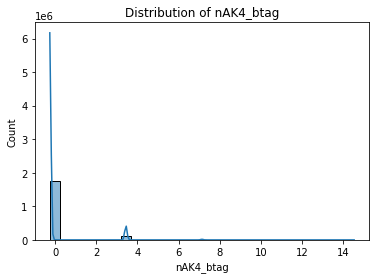

In [52]:
from tensorflow.keras.layers import Normalization
import numpy as np

# First approach
normalizer = Normalization(
    mean=X_train.mean(axis=0).to_numpy(),
    variance=X_train.var(axis=0).to_numpy()
)

X_normalized = normalizer(X_train.to_numpy())
# Convert back to DataFrame to keep column names
X_normalized_df = pd.DataFrame(
    X_normalized.numpy(),  # Convert from tensor to numpy array
    columns=X_train.columns
)
X_normalized_df.describe().round(3)

datahandler.plot_feature_distribution(X_normalized_df, ['nAK4_btag'])

In [22]:
from tensorflow.keras.layers import Lambda
shift_layer = Lambda(lambda x: x + 5)(X_normalized_df)
shift_layer.describe().round(3)

,nAK4,nAK4_btag,lep0_pt,lep0_eta,lep0_phi,ak4_jet0_pt,ak4_jet0_eta,ak4_jet0_phi,ak4_jet1_pt,ak4_jet1_eta,ak4_jet1_phi,ak4_jet2_pt,ak4_jet2_eta,ak4_jet2_phi,ak4_btag0_pt,ak4_btag0_eta,ak4_btag0_phi,ak4_btag1_pt,ak4_btag1_eta,ak4_btag1_phi,met_pt,met_phi,bjets_mbb,bjets_dPhi,bjets_dR,bjets_pt_bb,trijet_mInv,trijet_pt,trijet_pt_rat,blnu_mT,blnu_pt,trijet_bijet_dR,trijet_bijet_dPhi,bjet_bijet_dR,bjet_bijet_dPhi,all_pt,all_mInv,all_jets_HT
count,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000
mean,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,4.254,4.735,3.842,2.680,3.271,3.696,2.885,3.266,3.661,2.897,3.269,3.726,2.958,3.270,3.697,2.771,3.270,3.944,2.870,3.270,3.580,3.269,3.608,3.497,2.604,3.506,3.665,3.273,1.339,3.060,3.314,3.844,0.763,2.752,2.969,3.889,3.430,3.556
25%,4.254,4.735,4.345,4.266,4.134,4.401,4.246,4.137,4.380,4.250,4.134,4.343,4.239,4.134,4.382,4.262,4.135,4.305,4.252,4.135,4.330,4.133,4.352,4.017,4.288,4.363,4.386,4.361,4.303,4.352,4.346,4.326,4.528,4.256,4.159,4.391,4.344,4.361
50%,4.254,4.735,4.733,5.001,4.997,4.739,5.000,4.999,4.766,4.999,4.999,4.767,5.000,4.998,4.784,5.000,4.997,4.742,5.001,4.999,4.788,5.001,4.767,4.996,5.111,4.836,4.682,4.787,5.102,4.791,4.805,4.688,4.999,4.906,5.001,4.738,4.742,4.756
75%,5.358,4.735,5.346,5.734,5.867,5.260,5.752,5.866,5.327,5.750,5.867,5.375,5.760,5.867,5.337,5.736,5.868,5.398,5.748,5.866,5.409,5.868,5.372,5.984,5.739,5.398,5.294,5.372,5.815,5.391,5.417,5.321,5.471,5.647,5.841,5.267,5.353,5.341
max,14.187,19.539,36.435,7.319,6.733,34.545,7.116,6.730,42.851,7.104,6.729,40.505,7.043,6.732,44.849,7.229,6.730,42.892,7.128,6.731,72.086,6.727,38.745,6.507,9.035,31.702,32.681,31.919,6.630,38.132,45.338,16.583,9.234,14.218,7.030,104.593,25.263,32.099


In [35]:
X_train.describe().round(3)

,nAK4,nAK4_btag,lep0_pt,lep0_eta,lep0_phi,ak4_jet0_pt,ak4_jet0_eta,ak4_jet0_phi,ak4_jet1_pt,ak4_jet1_eta,ak4_jet1_phi,ak4_jet2_pt,ak4_jet2_eta,ak4_jet2_phi,ak4_btag0_pt,ak4_btag0_eta,ak4_btag0_phi,ak4_btag1_pt,ak4_btag1_eta,ak4_btag1_phi,met_pt,met_phi,bjets_mbb,bjets_dPhi,bjets_dEta,bjets_dR,bjets_pt_bb,trijet_mInv,trijet_pt,trijet_pt_rat,blnu_mT,blnu_pt,trijet_bijet_dR,trijet_bijet_dPhi,bjet_bijet_dR,bjet_bijet_dPhi,all_pt,all_mInv,all_jets_HT,mjj
count,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000
mean,4.676,2.072,63.342,0.000,-0.004,139.410,-0.000,0.003,91.244,-0.000,0.001,62.917,-0.000,-0.002,109.640,-0.000,-0.000,59.954,0.001,-0.001,79.401,0.003,171.439,-0.004,0.001,2.362,98.670,276.293,168.410,0.701,273.083,157.455,0.799,0.001,1.993,0.001,41.717,730.801,363.378,144.579
std,0.906,0.270,41.759,1.078,1.815,86.539,1.134,1.814,49.199,1.141,1.816,29.746,1.175,1.815,64.902,1.077,1.816,33.110,1.127,1.815,55.883,1.817,114.012,2.088,1.381,0.828,65.983,186.472,95.432,0.184,113.584,93.293,0.690,0.742,0.886,1.547,37.497,357.447,179.071,135.763
min,4.000,2.000,15.000,-2.500,-3.142,26.578,-2.400,-3.142,25.359,-2.400,-3.142,25.016,-2.400,-3.142,25.047,-2.400,-3.142,25.016,-2.400,-3.142,0.049,-3.142,12.803,-3.142,-4.781,0.378,0.072,27.437,3.581,0.029,52.767,0.172,0.001,-3.142,0.002,-3.142,0.042,169.577,104.828,11.726
25%,4.000,2.000,35.970,-0.790,-1.576,87.562,-0.855,-1.563,60.750,-0.857,-1.571,43.344,-0.894,-1.574,69.500,-0.795,-1.570,36.938,-0.842,-1.572,41.955,-1.572,97.540,-2.057,-0.962,1.772,56.661,161.886,107.432,0.573,199.447,96.430,0.334,-0.349,1.334,-1.301,18.863,496.257,248.969,71.927
50%,4.000,2.000,52.178,0.001,-0.009,116.812,0.000,0.002,79.750,-0.002,-0.001,56.000,-0.000,-0.005,95.625,-0.000,-0.005,51.406,0.002,-0.004,67.573,0.005,144.837,-0.012,0.001,2.454,87.820,216.994,148.071,0.720,249.353,139.247,0.584,0.001,1.910,0.002,31.902,638.410,319.625,97.576
75%,5.000,2.000,77.788,0.792,1.569,161.875,0.853,1.573,107.312,0.856,1.575,74.062,0.892,1.571,131.500,0.792,1.575,73.125,0.844,1.571,102.261,1.581,213.864,2.052,0.964,2.974,124.937,331.156,203.913,0.850,317.522,196.400,1.020,0.350,2.566,1.303,51.720,856.923,424.453,170.641
max,13.000,6.000,1376.128,2.500,3.142,2696.000,2.400,3.142,1953.000,2.400,3.142,1119.000,2.400,3.142,2696.000,2.400,3.142,1314.000,2.400,3.142,3828.651,3.142,4018.068,3.142,4.791,5.704,1860.764,5438.138,2737.176,1.000,4036.089,3920.751,8.795,3.142,10.156,3.142,3776.636,7973.377,5215.375,4661.124


In [27]:
normalizer = Normalization(name='normalization')
normalizer.adapt(X_train)
normalized_input = normalizer(X_train)
shifted_input = Lambda(lambda x: x+5)(normalized_input)
X_shifted = pd.DataFrame(
    shifted_input,  # Convert from tensor to numpy array
    columns=X_train.columns
)
X_shifted.describe().round(3)

,nAK4,nAK4_btag,lep0_pt,lep0_eta,lep0_phi,ak4_jet0_pt,ak4_jet0_eta,ak4_jet0_phi,ak4_jet1_pt,ak4_jet1_eta,ak4_jet1_phi,ak4_jet2_pt,ak4_jet2_eta,ak4_jet2_phi,ak4_btag0_pt,ak4_btag0_eta,ak4_btag0_phi,ak4_btag1_pt,ak4_btag1_eta,ak4_btag1_phi,met_pt,met_phi,bjets_mbb,bjets_dPhi,bjets_dR,bjets_pt_bb,trijet_mInv,trijet_pt,trijet_pt_rat,blnu_mT,blnu_pt,trijet_bijet_dR,trijet_bijet_dPhi,bjet_bijet_dR,bjet_bijet_dPhi,all_pt,all_mInv,all_jets_HT
count,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000
mean,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.001,5.000,5.000,5.000,5.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,4.254,4.735,3.843,2.680,3.271,3.696,2.885,3.266,3.661,2.897,3.269,3.726,2.958,3.270,3.697,2.771,3.270,3.944,2.870,3.270,3.580,3.269,3.608,3.497,2.604,3.506,3.665,3.273,1.339,3.060,3.314,3.844,0.763,2.753,2.969,3.889,3.430,3.556
25%,4.254,4.735,4.345,4.266,4.134,4.401,4.246,4.137,4.380,4.250,4.134,4.343,4.239,4.134,4.382,4.262,4.135,4.305,4.252,4.135,4.330,4.133,4.352,4.017,4.288,4.363,4.386,4.361,4.303,4.352,4.346,4.326,4.528,4.257,4.159,4.391,4.344,4.361
50%,4.254,4.735,4.733,5.001,4.997,4.739,5.000,4.999,4.766,4.999,4.999,4.768,5.000,4.998,4.784,5.000,4.997,4.742,5.001,4.999,4.788,5.001,4.767,4.996,5.111,4.836,4.682,4.787,5.102,4.791,4.805,4.688,4.999,4.907,5.001,4.738,4.742,4.756
75%,5.358,4.735,5.346,5.734,5.867,5.260,5.752,5.866,5.327,5.750,5.867,5.375,5.760,5.867,5.337,5.736,5.868,5.398,5.748,5.866,5.409,5.868,5.372,5.984,5.739,5.398,5.294,5.372,5.815,5.391,5.417,5.321,5.471,5.648,5.841,5.267,5.353,5.341
max,14.187,19.538,36.435,7.319,6.733,34.545,7.116,6.730,42.851,7.104,6.729,40.505,7.043,6.732,44.848,7.229,6.730,42.891,7.128,6.731,72.087,6.727,38.745,6.507,9.035,31.702,32.682,31.920,6.630,38.132,45.337,16.583,9.234,14.218,7.030,104.595,25.263,32.100


In [31]:
# I want to see now how minmax scaling would affect my X_train, using the tensorflow machinery of Rescaling layer
import tensorflow as tf
from tensorflow.keras.layers import Rescaling
# Calculate the scaling factors
x_min = tf.reduce_min(X_train, axis=0)
x_max = tf.reduce_max(X_train, axis=0)
scale = x_max - x_min
offset = x_min

X_train_rescaled = Rescaling(scale=1.0/scale, offset=-offset/scale)(X_train)
X_train_rescaled_df = pd.DataFrame(
    X_train_rescaled.numpy(),
    columns=X_train.columns
)
X_train_rescaled_df.describe().round(3)

,nAK4,nAK4_btag,lep0_pt,lep0_eta,lep0_phi,ak4_jet0_pt,ak4_jet0_eta,ak4_jet0_phi,ak4_jet1_pt,ak4_jet1_eta,ak4_jet1_phi,ak4_jet2_pt,ak4_jet2_eta,ak4_jet2_phi,ak4_btag0_pt,ak4_btag0_eta,ak4_btag0_phi,ak4_btag1_pt,ak4_btag1_eta,ak4_btag1_phi,met_pt,met_phi,bjets_mbb,bjets_dPhi,bjets_dR,bjets_pt_bb,trijet_mInv,trijet_pt,trijet_pt_rat,blnu_mT,blnu_pt,trijet_bijet_dR,trijet_bijet_dPhi,bjet_bijet_dR,bjet_bijet_dPhi,all_pt,all_mInv,all_jets_HT
count,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000
mean,0.075,0.018,0.036,0.500,0.499,0.042,0.500,0.500,0.034,0.500,0.500,0.035,0.500,0.500,0.032,0.500,0.500,0.027,0.500,0.500,0.021,0.501,0.040,0.499,0.373,0.053,0.046,0.060,0.692,0.055,0.040,0.091,0.500,0.196,0.500,0.011,0.072,0.051
std,0.101,0.068,0.031,0.216,0.289,0.032,0.236,0.289,0.026,0.238,0.289,0.027,0.245,0.289,0.024,0.224,0.289,0.026,0.235,0.289,0.015,0.289,0.028,0.332,0.155,0.035,0.034,0.035,0.189,0.029,0.024,0.078,0.118,0.087,0.246,0.010,0.046,0.035
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.015,0.342,0.249,0.023,0.322,0.251,0.018,0.322,0.250,0.017,0.314,0.250,0.017,0.334,0.250,0.009,0.325,0.250,0.011,0.250,0.021,0.173,0.262,0.030,0.025,0.038,0.560,0.037,0.025,0.038,0.444,0.131,0.293,0.005,0.042,0.028
50%,0.000,0.000,0.027,0.500,0.499,0.034,0.500,0.500,0.028,0.500,0.500,0.028,0.500,0.499,0.026,0.500,0.499,0.020,0.500,0.499,0.018,0.501,0.033,0.498,0.390,0.047,0.035,0.053,0.711,0.049,0.035,0.066,0.500,0.188,0.500,0.008,0.060,0.042
75%,0.111,0.000,0.046,0.658,0.750,0.051,0.678,0.750,0.043,0.678,0.751,0.045,0.686,0.750,0.040,0.665,0.751,0.037,0.676,0.750,0.027,0.752,0.050,0.827,0.488,0.067,0.056,0.073,0.846,0.066,0.050,0.116,0.556,0.252,0.707,0.014,0.088,0.063
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


In [47]:
X_train_rescaled_df.quantile(0.75).to_frame().T.round(3)

,nAK4,nAK4_btag,lep0_pt,lep0_eta,lep0_phi,ak4_jet0_pt,ak4_jet0_eta,ak4_jet0_phi,ak4_jet1_pt,ak4_jet1_eta,ak4_jet1_phi,ak4_jet2_pt,ak4_jet2_eta,ak4_jet2_phi,ak4_btag0_pt,ak4_btag0_eta,ak4_btag0_phi,ak4_btag1_pt,ak4_btag1_eta,ak4_btag1_phi,met_pt,met_phi,bjets_mbb,bjets_dPhi,bjets_dR,bjets_pt_bb,trijet_mInv,trijet_pt,trijet_pt_rat,blnu_mT,blnu_pt,trijet_bijet_dR,trijet_bijet_dPhi,bjet_bijet_dR,bjet_bijet_dPhi,all_pt,all_mInv,all_jets_HT
0.75,0.111,0.0,0.046,0.658,0.75,0.051,0.678,0.75,0.043,0.678,0.751,0.045,0.686,0.75,0.04,0.665,0.751,0.037,0.676,0.75,0.027,0.752,0.05,0.827,0.488,0.067,0.056,0.073,0.846,0.066,0.05,0.116,0.556,0.252,0.707,0.014,0.088,0.063


Plotting feature distributions ...


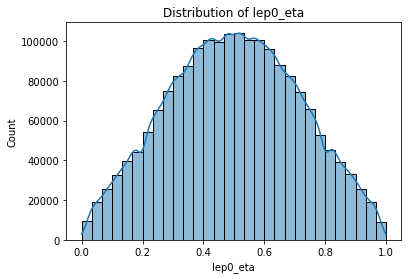

In [44]:
datahandler.plot_feature_distribution(X_train_rescaled_df, ['lep0_eta'])

In [46]:
lower_threshold = X_train.quantile(0.01)
upper_threshold = X_train.quantile(0.99)
# Create a new dataframe to use normalizer.adapt() on but that doesn't include the outliers
X_train_noOutliers = X_train[(X_train > lower_threshold) & (X_train < upper_threshold)]

In [45]:
X_train.describe().round(3)

,lep0_pt,lep0_eta,lep0_phi,ak4_jet0_pt,ak4_jet0_eta,ak4_jet0_phi,ak4_jet1_pt,ak4_jet1_eta,ak4_jet1_phi,ak4_jet2_pt,ak4_jet2_eta,ak4_jet2_phi,ak4_btag0_pt,ak4_btag0_eta,ak4_btag0_phi,ak4_btag1_pt,ak4_btag1_eta,ak4_btag1_phi,met_pt,met_phi,nAK4,nAK4_btag,nAK4_nonbtag,nAK8_btag,bjets_mbb,bjets_dPhi,bjets_dPhi_abs,bjets_dEta,bjets_dEta_abs,bjets_dR,bjets_pt_bb,bjet0_pt,bjet1_pt,bjets_mean_pt,trijet_mInv,trijet_pt,trijet_pt_rat,blnu_mT,blnu_pt,trijet_bijet_dR,trijet_bijet_dPhi,trijet_bijet_dEta,bjet_bijet_dR,bjet_bijet_dPhi,bjet_bijet_dEta,all_sT,all_sT_50_cut,all_mInv,all_mT,all_jets_HT,all_pt,mjj,WW_mInv
count,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.0,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000,1872627.000
mean,63.342,0.000,-0.004,139.410,-0.000,0.003,91.244,-0.000,0.001,62.917,-0.000,-0.002,109.640,-0.000,-0.000,59.954,0.001,-0.001,79.401,0.003,4.676,2.072,2.604,0.0,171.439,-0.004,1.903,0.001,1.117,2.362,98.670,87.912,79.939,83.926,276.293,168.410,0.701,273.083,157.455,0.799,0.001,0.000,1.993,0.001,0.001,506.121,384.558,730.801,733.120,363.378,41.717,144.579,388.203
std,41.759,1.078,1.815,86.539,1.134,1.814,49.199,1.141,1.816,29.746,1.175,1.815,64.902,1.077,1.816,33.110,1.127,1.815,55.883,1.817,0.906,0.270,0.867,0.0,114.012,2.088,0.860,1.381,0.811,0.828,65.983,55.418,57.503,43.027,186.472,95.432,0.184,113.584,93.293,0.690,0.742,0.751,0.886,1.547,1.537,216.064,601.455,357.447,357.099,179.071,37.497,135.763,213.904
min,15.000,-2.500,-3.142,26.578,-2.400,-3.142,25.359,-2.400,-3.142,25.016,-2.400,-3.142,25.047,-2.400,-3.142,25.016,-2.400,-3.142,0.049,-3.142,4.000,2.000,2.000,0.0,12.803,-3.142,0.000,-4.781,0.000,0.378,0.072,25.016,25.016,25.039,27.437,3.581,0.029,52.767,0.172,0.001,-3.142,-7.052,0.002,-3.142,-8.152,143.408,-9999.000,169.577,176.742,104.828,0.042,11.726,39.976
25%,35.970,-0.790,-1.576,87.562,-0.855,-1.563,60.750,-0.857,-1.571,43.344,-0.894,-1.574,69.500,-0.795,-1.570,36.938,-0.842,-1.572,41.955,-1.572,4.000,2.000,2.000,0.0,97.540,-2.057,1.244,-0.962,0.469,1.772,56.661,50.812,42.625,56.203,161.886,107.432,0.573,199.447,96.430,0.334,-0.349,-0.324,1.334,-1.301,-1.014,369.180,260.375,496.257,498.851,248.969,18.863,71.927,251.851
50%,52.178,0.001,-0.009,116.812,0.000,0.002,79.750,-0.002,-0.001,56.000,-0.000,-0.005,95.625,-0.000,-0.005,51.406,0.002,-0.004,67.573,0.005,4.000,2.000,2.000,0.0,144.837,-0.012,2.054,0.001,0.963,2.454,87.820,75.375,65.188,74.656,216.994,148.071,0.720,249.353,139.247,0.584,0.001,0.000,1.910,0.002,0.002,454.271,366.833,638.410,640.838,319.625,31.902,97.576,333.245
75%,77.788,0.792,1.569,161.875,0.853,1.573,107.312,0.856,1.575,74.062,0.892,1.571,131.500,0.792,1.575,73.125,0.844,1.571,102.261,1.581,5.000,2.000,3.000,0.0,213.864,2.052,2.640,0.964,1.609,2.974,124.937,109.500,99.250,99.922,331.156,203.913,0.850,317.522,196.400,1.020,0.350,0.325,2.566,1.303,1.015,578.847,506.590,856.923,859.027,424.453,51.720,170.641,458.153
max,1376.128,2.500,3.142,2696.000,2.400,3.142,1953.000,2.400,3.142,1119.000,2.400,3.142,2696.000,2.400,3.142,1314.000,2.400,3.142,3828.651,3.142,13.000,6.000,11.000,0.0,4018.068,3.142,3.142,4.791,4.791,5.704,1860.764,2696.000,1953.000,2005.000,5438.138,2737.176,1.000,4036.089,3920.751,8.795,3.142,8.776,10.156,3.142,10.140,5662.956,5642.999,7973.377,7973.905,5215.375,3776.636,4661.124,5636.316


In [47]:
lower_threshold.to_frame().T

,lep0_pt,lep0_eta,lep0_phi,ak4_jet0_pt,ak4_jet0_eta,ak4_jet0_phi,ak4_jet1_pt,ak4_jet1_eta,ak4_jet1_phi,ak4_jet2_pt,ak4_jet2_eta,ak4_jet2_phi,ak4_btag0_pt,ak4_btag0_eta,ak4_btag0_phi,ak4_btag1_pt,ak4_btag1_eta,ak4_btag1_phi,met_pt,met_phi,nAK4,nAK4_btag,nAK4_nonbtag,nAK8_btag,bjets_mbb,bjets_dPhi,bjets_dPhi_abs,bjets_dEta,bjets_dEta_abs,bjets_dR,bjets_pt_bb,bjet0_pt,bjet1_pt,bjets_mean_pt,trijet_mInv,trijet_pt,trijet_pt_rat,blnu_mT,blnu_pt,trijet_bijet_dR,trijet_bijet_dPhi,trijet_bijet_dEta,bjet_bijet_dR,bjet_bijet_dPhi,bjet_bijet_dEta,all_sT,all_sT_50_cut,all_mInv,all_mT,all_jets_HT,all_pt,mjj,WW_mInv
0.01,17.047588,-2.246658,-3.07782,47.3125,-2.271484,-3.078125,34.71875,-2.281738,-3.078125,28.0,-2.301758,-3.07959,33.625,-2.233398,-3.079102,25.453125,-2.27832,-3.079102,7.67274,-3.080078,4.0,2.0,2.0,0.0,31.810305,-3.102295,0.068115,-3.132812,0.018722,0.556675,9.809289,26.21875,25.640625,30.929688,77.993678,41.118987,0.246307,116.304129,23.6046,0.069968,-2.330981,-2.230007,0.330926,-2.950531,-3.595722,244.082017,62.9375,308.917448,311.750798,151.828125,3.26808,26.071794,138.057929


In [48]:
upper_threshold.to_frame().T

,lep0_pt,lep0_eta,lep0_phi,ak4_jet0_pt,ak4_jet0_eta,ak4_jet0_phi,ak4_jet1_pt,ak4_jet1_eta,ak4_jet1_phi,ak4_jet2_pt,ak4_jet2_eta,ak4_jet2_phi,ak4_btag0_pt,ak4_btag0_eta,ak4_btag0_phi,ak4_btag1_pt,ak4_btag1_eta,ak4_btag1_phi,met_pt,met_phi,nAK4,nAK4_btag,nAK4_nonbtag,nAK8_btag,bjets_mbb,bjets_dPhi,bjets_dPhi_abs,bjets_dEta,bjets_dEta_abs,bjets_dR,bjets_pt_bb,bjet0_pt,bjet1_pt,bjets_mean_pt,trijet_mInv,trijet_pt,trijet_pt_rat,blnu_mT,blnu_pt,trijet_bijet_dR,trijet_bijet_dPhi,trijet_bijet_dEta,bjet_bijet_dR,bjet_bijet_dPhi,bjet_bijet_dEta,all_sT,all_sT_50_cut,all_mInv,all_mT,all_jets_HT,all_pt,mjj,WW_mInv
0.99,215.617739,2.246582,3.078125,482.25,2.270996,3.079102,273.0,2.280635,3.079102,168.875,2.29834,3.078975,349.25,2.230469,3.078613,174.375,2.273438,3.078613,274.784521,3.07959,8.0,3.0,5.0,0.0,582.439994,3.102051,3.12193,3.135986,3.437988,4.172188,330.702646,283.75,289.5,237.8125,990.383414,518.454421,0.989792,677.93406,483.607385,3.271417,2.342809,2.230775,4.349229,2.949557,3.597436,1320.168617,1267.824596,2055.102593,2056.380576,1033.4375,190.460053,688.973505,1192.829939


In [ ]:
def plot_feature_comparison(X_train, X_normalized, feature_name):
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Create figure
    plt.figure(figsize=(10, 6))
    
    # sns.histplot(data=X_train, x=feature_name, label=f'Original (n={len(X_train):,})', alpha=0.5, color='blue')
    sns.histplot(data=X_normalized, x=feature_name, label=f'Normalized (n={len(X_normalized):,})', alpha=0.5, color='red')
    
    plt.title(f'Distribution of {feature_name} (Log Scale)')
    plt.xlabel(f'{feature_name}')
    plt.ylabel('Count')
    plt.yscale('log')  # Set y-axis to log scale
    plt.legend()
    
    # Add statistics text
    stats_text = (
        f'Original  - Mean: {X_train[feature_name].mean():.2f}, Std: {X_train[feature_name].std():.2f}\n'
        f'Normalized - Mean: {X_normalized[feature_name].mean():.2f}, Std: {X_normalized[feature_name].std():.2f}'
    )
    plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

plot_feature_comparison(X_train, X_normalized, 'ak4_jet0_pt')
plot_feature_comparison(X_train, X_normalized, 'ak4_jet2_pt')

In [33]:
min_of_all_features = X_normalized.describe().round(2).loc[['min']]
min_of_all_features

,nAK4,nAK4_btag,lep0_pt,lep0_eta,lep0_phi,ak4_jet0_pt,ak4_jet0_eta,ak4_jet0_phi,ak4_jet1_pt,ak4_jet1_eta,ak4_jet1_phi,ak4_jet2_pt,ak4_jet2_eta,ak4_jet2_phi,ak4_btag0_pt,ak4_btag0_eta,ak4_btag0_phi,ak4_btag1_pt,ak4_btag1_eta,ak4_btag1_phi,met_pt,met_phi,bjets_mbb,bjets_dPhi,bjets_dEta,bjets_dR,bjets_pt_bb,trijet_mInv,trijet_pt,trijet_pt_rat,blnu_mT,blnu_pt,trijet_bijet_dR,trijet_bijet_dPhi,bjet_bijet_dR,bjet_bijet_dPhi,all_pt,all_mInv,all_jets_HT,mjj
min,-0.75,-0.26,-1.16,-2.32,-1.73,-1.3,-2.12,-1.73,-1.34,-2.1,-1.73,-1.27,-2.04,-1.73,-1.3,-2.23,-1.73,-1.06,-2.13,-1.73,-1.42,-1.73,-1.39,-1.5,-3.46,-2.4,-1.49,-1.33,-1.73,-3.66,-1.94,-1.69,-1.16,-4.24,-2.25,-2.03,-1.11,-1.57,-1.44,-0.98


In [31]:
min(min(min_of_all_features.values.tolist()))

-4.24

In [16]:
(X_normalized + 3).describe().round(2)


,nAK4,nAK4_btag,lep0_pt,lep0_eta,lep0_phi,ak4_jet0_pt,ak4_jet0_eta,ak4_jet0_phi,ak4_jet1_pt,ak4_jet1_eta,ak4_jet1_phi,ak4_jet2_pt,ak4_jet2_eta,ak4_jet2_phi,ak4_btag0_pt,ak4_btag0_eta,ak4_btag0_phi,ak4_btag1_pt,ak4_btag1_eta,ak4_btag1_phi,met_pt,met_phi,bjets_mbb,bjets_dPhi,bjets_dEta,bjets_dR,bjets_pt_bb,trijet_mInv,trijet_pt,trijet_pt_rat,blnu_mT,blnu_pt,trijet_bijet_dR,trijet_bijet_dPhi,bjet_bijet_dR,bjet_bijet_dPhi,all_pt,all_mInv,all_jets_HT,mjj
count,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00,1872627.00
mean,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00,3.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,2.25,2.74,1.84,0.68,1.27,1.70,0.88,1.27,1.66,0.90,1.27,1.73,0.96,1.27,1.70,0.77,1.27,1.94,0.87,1.27,1.58,1.27,1.61,1.50,-0.46,0.60,1.51,1.67,1.27,-0.66,1.06,1.31,1.84,-1.24,0.75,0.97,1.89,1.43,1.56,2.02
25%,2.25,2.74,2.34,2.27,2.13,2.40,2.25,2.14,2.38,2.25,2.13,2.34,2.24,2.13,2.38,2.26,2.14,2.30,2.25,2.13,2.33,2.13,2.35,2.02,2.30,2.29,2.36,2.39,2.36,2.30,2.35,2.35,2.33,2.53,2.26,2.16,2.39,2.34,2.36,2.46
50%,2.25,2.74,2.73,3.00,3.00,2.74,3.00,3.00,2.77,3.00,3.00,2.77,3.00,3.00,2.78,3.00,3.00,2.74,3.00,3.00,2.79,3.00,2.77,3.00,3.00,3.11,2.84,2.68,2.79,3.10,2.79,2.80,2.69,3.00,2.91,3.00,2.74,2.74,2.76,2.65
75%,3.36,2.74,3.35,3.73,3.87,3.26,3.75,3.87,3.33,3.75,3.87,3.37,3.76,3.87,3.34,3.74,3.87,3.40,3.75,3.87,3.41,3.87,3.37,3.98,3.70,3.74,3.40,3.29,3.37,3.82,3.39,3.42,3.32,3.47,3.65,3.84,3.27,3.35,3.34,3.19
max,12.19,17.54,34.44,5.32,4.73,32.54,5.12,4.73,40.84,5.10,4.73,38.50,5.04,4.73,42.85,5.23,4.73,40.87,5.13,4.73,70.09,4.73,36.74,4.51,6.47,7.03,29.71,30.68,29.92,4.63,36.13,43.34,14.58,7.23,12.22,5.03,102.60,23.26,30.10,36.27
